# RQ2: Which audio features have the strongest correlation with song popularity?

Dataset: Almost Million Songs Dataset (Kaggle)  
Target: Popularity  
Task: Exploratory Data Analysis (Correlation Analysis)

In [1]:
# ── Import libraries ─────────────────────────

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded ")

Libraries loaded 


In [2]:
# ── Load dataset ─────────────────────────

data_path = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            data_path = os.path.join(dirname, filename)
            print(f"Dataset found: {data_path}")
            break

df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Dataset found: /kaggle/input/datasets/anantsinghal786/almost-million-songs-dataset-2025-16-features/tracks.csv
Shape: (899702, 16)


,track_id,genres,track_artists,tempo,energy,key,popularity,mode,time_signature,speechiness,danceability,valence,acousticness,liveness,instrumentalness,name
0,07vS8obfeZbr8H4MgQfXR7,"['indie pop', 'la indie', 'pov: indie']",Phoebe Bridgers,97.129,0.123,7.0,0.0,1.0,4.0,0.0407,0.373,0.138,0.9480,0.0816,0.000000,Friday I'm In Love - Recorded at Spotify Studi...
1,1PEqh7awkpuepLBSq8ZwqD,"['lilith', 'new wave pop']",NaN,103.773,0.453,5.0,71.0,1.0,4.0,0.0348,0.744,0.122,0.6270,0.0898,0.421000,I Love You Always Forever
2,7E8pPgBY84oDaXRcqODavR,"['deep groove house', 'house', 'tech house']",NaN,122.030,0.878,9.0,0.0,0.0,4.0,0.0357,0.747,0.897,0.0794,0.3700,0.000531,Love Too Deep - Radio Edit
3,0Atml4huw4Fgyk6YSHiK4M,[],NaN,84.099,0.484,7.0,0.0,1.0,4.0,0.0356,0.604,0.564,0.1000,0.0865,0.000000,No Tiren Las Botellas
4,4WYDmIZrwxBHdBYdvi5oQO,"['chill lounge', 'deep chill']",NaN,156.017,0.447,0.0,7.0,1.0,4.0,0.0613,0.761,0.761,0.0616,0.0822,0.873000,El Momento de Despertar - Blue Sky Mix


In [3]:
# ── Preprocessing ─────────────────────────

TARGET = 'popularity'

drop_cols = [c for c in ['track_id','song_id','title','artist_name','name','id','genres','track_artists'] if c in df.columns]
df = df.drop(columns=drop_cols)

df = df.select_dtypes(include=[np.number])

df = df.dropna(subset=[TARGET])
df = df.fillna(df.median())

if len(df) > 150_000:
    df = df.sample(150_000, random_state=42).reset_index(drop=True)

print("Final shape:", df.shape)

Final shape: (150000, 12)


In [4]:
# ── Correlation Analysis ─────────────────────────

corr = df.corr(numeric_only=True)

target_corr = corr[TARGET].sort_values(ascending=False)

display(target_corr.head(10))

popularity        1.000000
energy            0.118494
danceability      0.115675
valence           0.059482
time_signature    0.039057
speechiness       0.035901
tempo             0.022443
key               0.002844
liveness          0.002121
mode             -0.011919
Name: popularity, dtype: float64

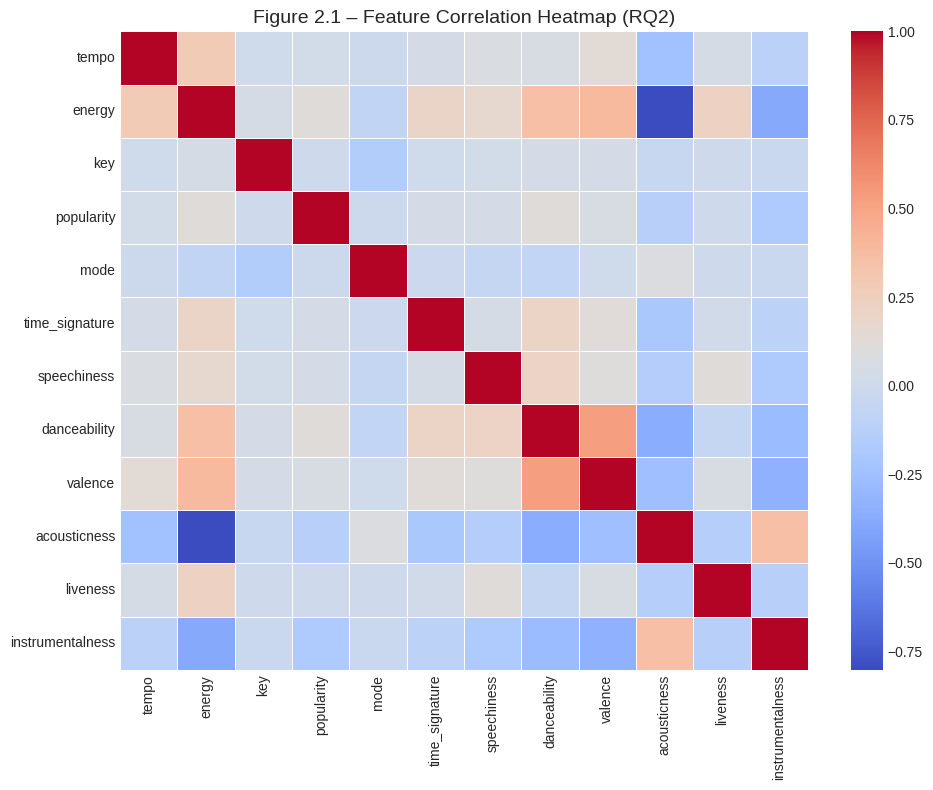

In [5]:
# ── Figure 2.1: Correlation Heatmap ─────────────────

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Figure 2.1 – Feature Correlation Heatmap (RQ2)", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# ── Table 2.1: Top Features ─────────────────────────

top_features = target_corr.drop(TARGET).head(10).reset_index()
top_features.columns = ['Feature', 'Correlation']

styled_table = top_features.style\
    .format({"Correlation": "{:.3f}"})\
    .set_caption("Table 2.1: Top Features Correlated with Popularity (RQ2)")\
    .background_gradient(cmap="Blues", subset=["Correlation"])\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-size', '12pt')]},
        {'selector': 'caption', 'props': [('font-size', '13pt'), ('font-weight', 'bold')]}
    ])

display(styled_table)

,Feature,Correlation
0,energy,0.118
1,danceability,0.116
2,valence,0.059
3,time_signature,0.039
4,speechiness,0.036
5,tempo,0.022
6,key,0.003
7,liveness,0.002
8,mode,-0.012
9,acousticness,-0.127


In [7]:
# ── Conclusion ─────────────────────────

top_feature = top_features.iloc[0]['Feature']
top_value = top_features.iloc[0]['Correlation']

print("Conclusion:")
print(f"'{top_feature}' has the strongest correlation with popularity ({top_value:.3f}).")
print("This shows audio features play a significant role in determining song popularity.")

Conclusion:
'energy' has the strongest correlation with popularity (0.118).
This shows audio features play a significant role in determining song popularity.
